1. Importing Libraries

In [10]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# Machine learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE
from fuzzywuzzy import process


# Progress bar
from tqdm import tqdm

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

2. Loading and Initial Data Exploration

In [2]:
# Load the dataset
music_data = pd.read_csv("spotify_data.csv")

# Display basic info
print("Dataset shape:", music_data.shape)
print("\nData types:")
print(music_data.info())

# Check for missing values
print("\nMissing values per column:")
print(music_data.isnull().sum())

# Remove rows with missing values
music_data.dropna(inplace=True)

# Filter only popular songs (popularity >= 40)
music_data = music_data[music_data['popularity'] >= 40]

# Remove unnecessary columns
music_data.drop(columns=['Unnamed: 0', 'track_id'], inplace=True)

print("\nFinal dataset shape after cleaning:", music_data.shape)

Dataset shape: (1159764, 20)

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 1159764 entries, 0 to 1159763
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1159764 non-null  int64  
 1   artist_name       1159749 non-null  str    
 2   track_name        1159763 non-null  str    
 3   track_id          1159764 non-null  str    
 4   popularity        1159764 non-null  int64  
 5   year              1159764 non-null  int64  
 6   genre             1159764 non-null  str    
 7   danceability      1159764 non-null  float64
 8   energy            1159764 non-null  float64
 9   key               1159764 non-null  int64  
 10  loudness          1159764 non-null  float64
 11  mode              1159764 non-null  int64  
 12  speechiness       1159764 non-null  float64
 13  acousticness      1159764 non-null  float64
 14  instrumentalness  1159764 non-null  float64
 15  liveness          

3. Data Visualization

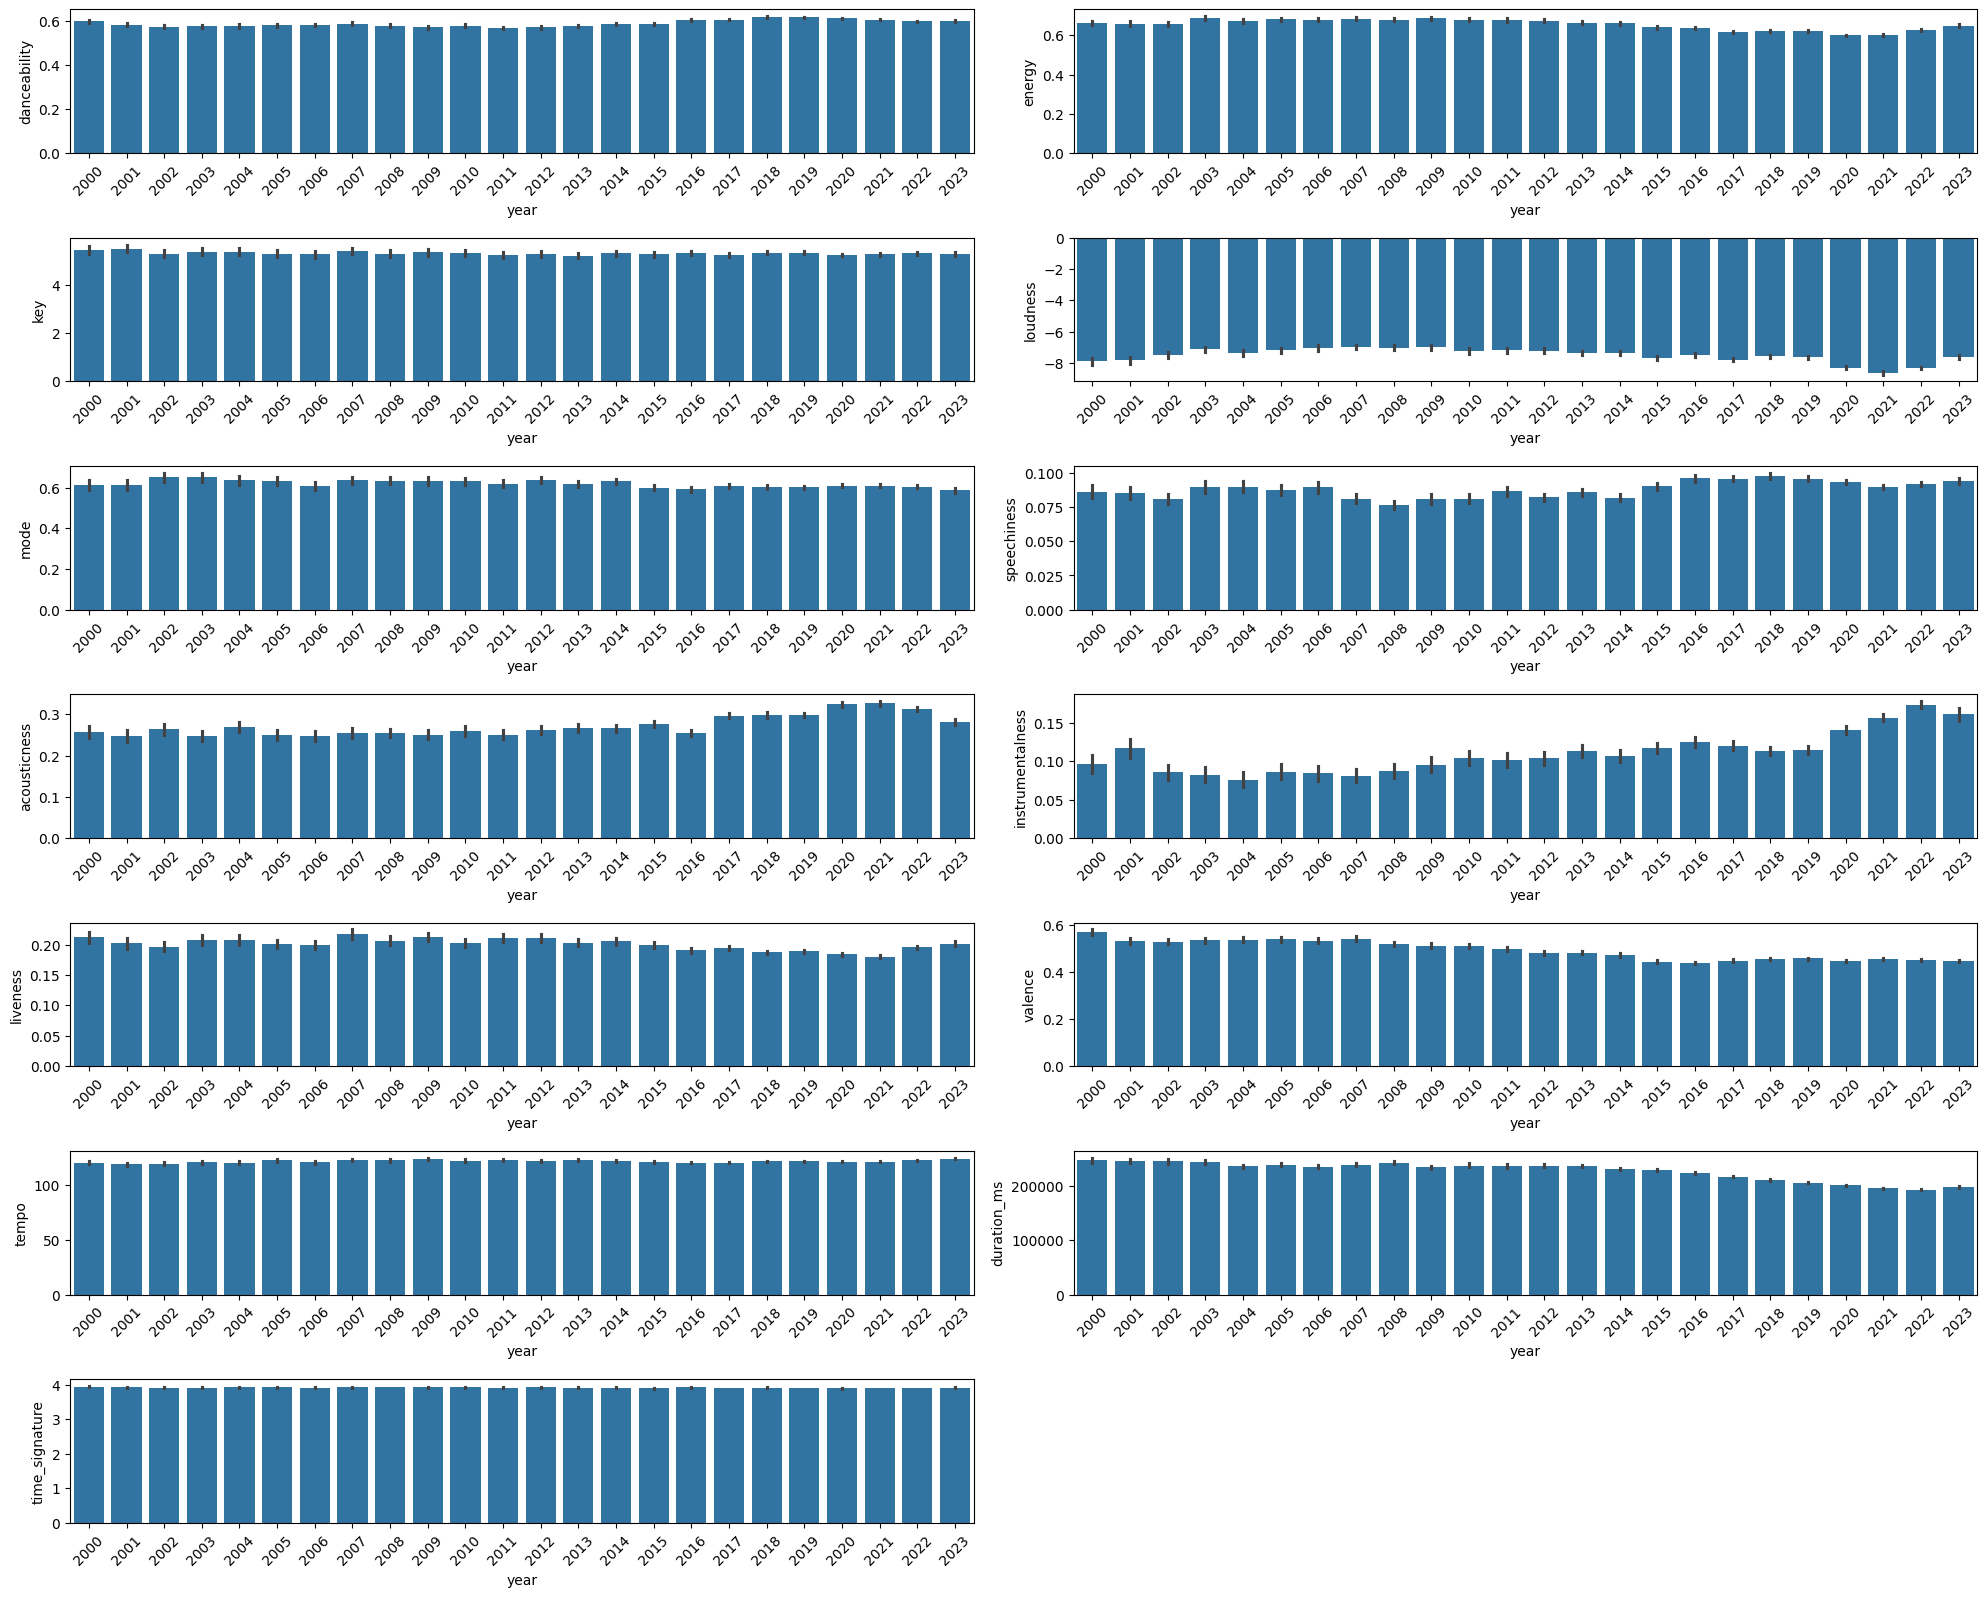

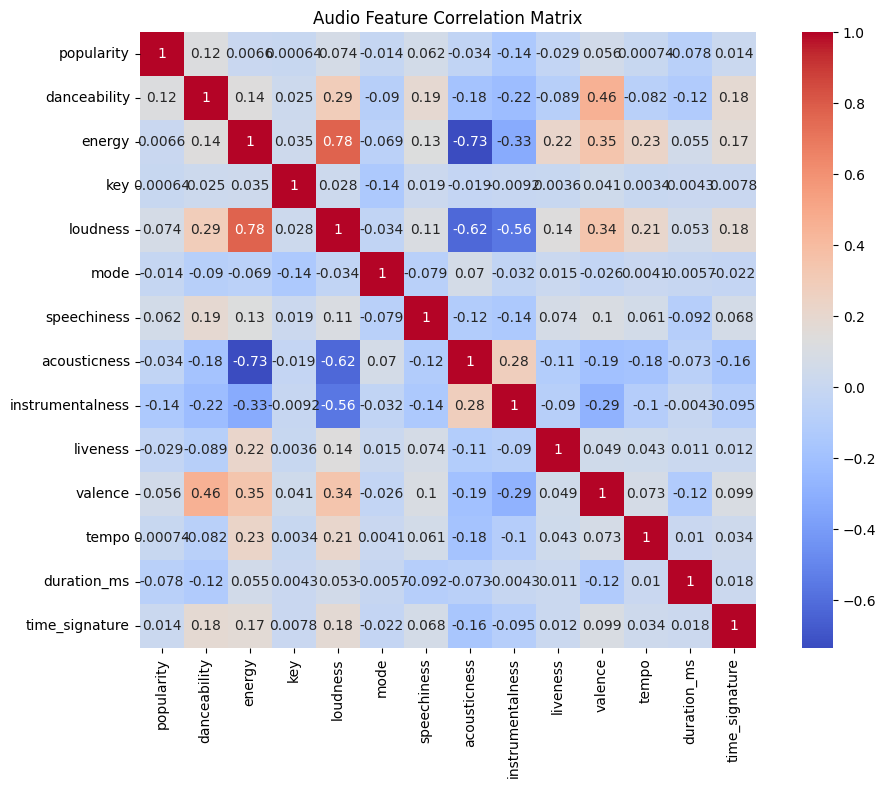

In [3]:
# Visualize audio features over time
visual_data = music_data.drop(columns=['track_name', 'artist_name', 'year', 'genre'])

plt.figure(figsize=(20, 20))
for i, column in enumerate(visual_data.columns[1:], 1):  # Skip the first column (popularity)
    plt.subplot(9, 2, i)
    sns.barplot(x=music_data.year, y=visual_data[column])
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation matrix visualization
plt.figure(figsize=(12, 8))
sns.heatmap(visual_data.corr(), annot=True, square=True, cmap='coolwarm')
plt.title("Audio Feature Correlation Matrix")
plt.show()

4. Data Preprocessing

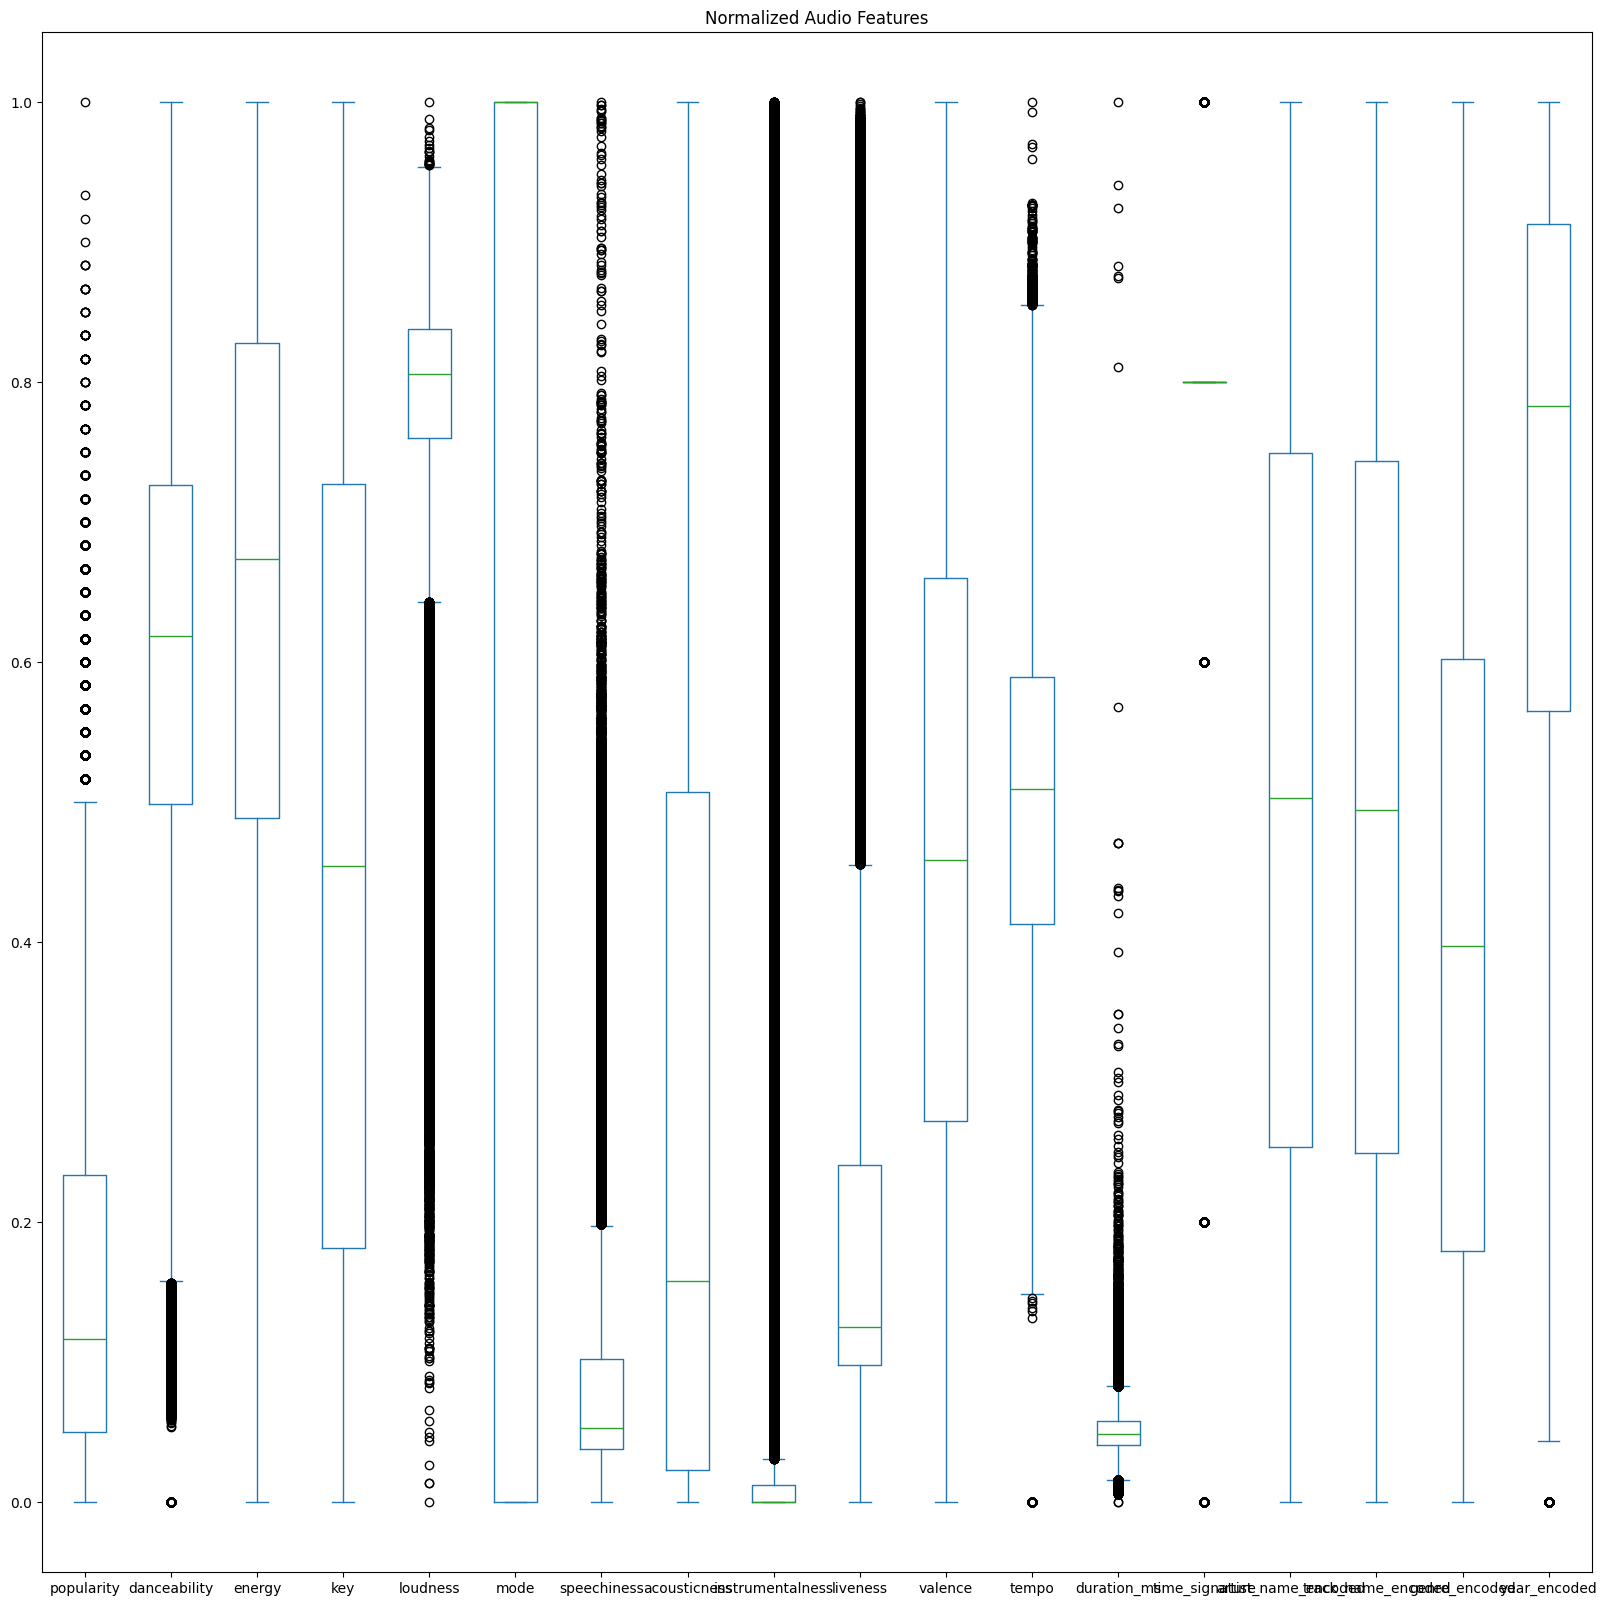

In [4]:
# Encode categorical features
label_encoder = LabelEncoder()
categorical_cols = ['artist_name', 'track_name', 'genre', 'year']

for col in categorical_cols:
    music_data[col + '_encoded'] = label_encoder.fit_transform(music_data[col])

# Normalize numerical features (except year)
def normalize_column(col):
    max_val = music_data[col].max()
    min_val = music_data[col].min()
    music_data[col] = (music_data[col] - min_val) / (max_val - min_val)

numerical_cols = music_data.select_dtypes(include=['int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns
for col in numerical_cols:
    if col != 'year':
        normalize_column(col)

# Visualize normalized features
music_data.select_dtypes(np.number).drop(columns=['year']).plot(kind='box', figsize=(20, 20), fontsize=10)
plt.title("Normalized Audio Features")
plt.show()

5. Clustering with K-Means

In [5]:
# Create a pipeline for clustering
cluster_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=10, random_state=42))
])

# Select numerical features for clustering
X = music_data.select_dtypes(np.number)

# Fit the pipeline and predict clusters
cluster_pipeline.fit(X)
music_data['cluster'] = cluster_pipeline.predict(X)

print("Cluster distribution:")
print(music_data['cluster'].value_counts())

Cluster distribution:
cluster
7    21338
3    19691
2    17122
1    15880
4    13734
0    13098
5     9765
8     9047
6     7210
9     6491
Name: count, dtype: int64


6. Building a Recommendation System with KNN

In [6]:
# Prepare data for KNN
X = music_data.select_dtypes(np.number).drop(columns=['cluster', 'year']).copy()
y = music_data['cluster']

# Split data into train, validation, and test sets
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.8, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_rem, y_rem, test_size=0.5)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)
print("Test set shape:", X_test.shape)

# Initialize KNN models with different k values
knn_models = {
    'knn1': KNeighborsClassifier(n_neighbors=1, metric='cosine', algorithm='brute'),
    'knn4': KNeighborsClassifier(n_neighbors=4, metric='cosine', algorithm='brute'),
    'knn20': KNeighborsClassifier(n_neighbors=20, metric='cosine', algorithm='brute')
}

# Train and evaluate models
for name, model in knn_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    accuracy = accuracy_score(y_valid, y_pred)
    print(f"\n{name} accuracy: {accuracy:.2%}")
    print("Classification Report:")
    print(classification_report(y_valid, y_pred))

Training set shape: (106700, 18)
Validation set shape: (13338, 18)
Test set shape: (13338, 18)

knn1 accuracy: 81.50%
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.71      1326
           1       0.85      0.84      0.84      1602
           2       0.78      0.82      0.80      1696
           3       0.85      0.83      0.84      1950
           4       0.77      0.83      0.79      1409
           5       0.79      0.64      0.71       983
           6       0.94      0.89      0.92       749
           7       0.82      0.88      0.85      2150
           8       0.82      0.90      0.86       884
           9       0.86      0.76      0.81       589

    accuracy                           0.82     13338
   macro avg       0.82      0.81      0.81     13338
weighted avg       0.82      0.82      0.81     13338


knn4 accuracy: 84.56%
Classification Report:
              precision    recall  f1-score   support


7. Visualization of Results

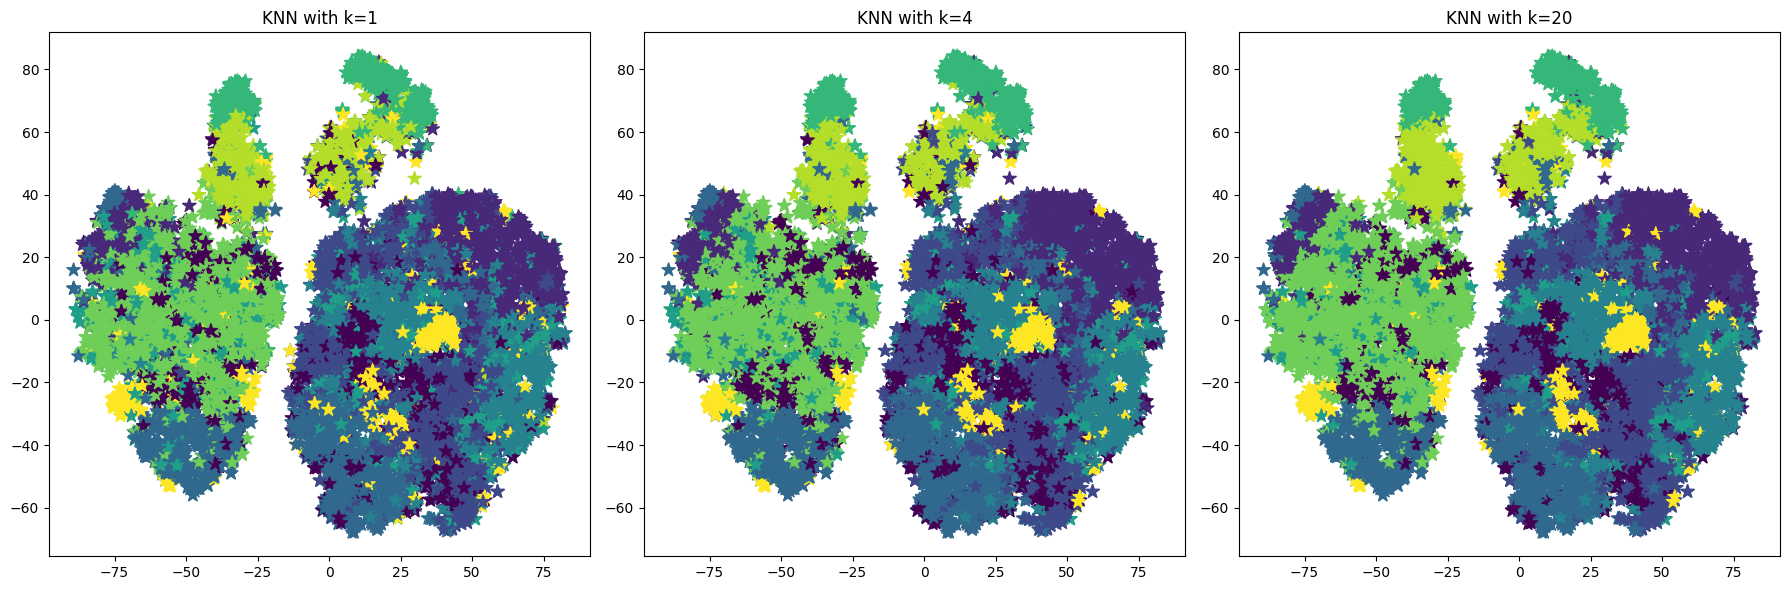

In [8]:
# Reduce dimensionality for visualization
tsne = TSNE(n_components=2, random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# Predict clusters for test set
y_pred_1 = knn_models['knn1'].predict(X_test)
y_pred_4 = knn_models['knn4'].predict(X_test)
y_pred_20 = knn_models['knn20'].predict(X_test)

# Plot results
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_pred_1, cmap='viridis', marker='*', s=100)
plt.title("KNN with k=1")

plt.subplot(1, 3, 2)
plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_pred_4, cmap='viridis', marker='*', s=100)
plt.title("KNN with k=4")

plt.subplot(1, 3, 3)
plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_pred_20, cmap='viridis', marker='*', s=100)
plt.title("KNN with k=20")

plt.tight_layout()
plt.show()

In [11]:
def recommend_songs(input_song_name, n_recommendations=5):
    """
    Recommends similar songs based on the input song name using the trained KNN model.
    
    Parameters:
    - input_song_name (str): Name of the song to find recommendations for
    - n_recommendations (int): Number of recommendations to return
    
    Returns:
    - DataFrame with recommended songs and their artists
    """
    # Fuzzy matching to find the closest song name in the dataset
    all_song_names = music_data['track_name'].unique()
    matched_song, score = process.extractOne(input_song_name, all_song_names)
    
    print(f"\nFinding recommendations for: '{matched_song}' (match score: {score}/100)")
    
    if score < 60:
        print("Warning: The song match quality is low. Recommendations may not be accurate.")
    
    # Get all matching songs (there might be multiple versions)
    matching_songs = music_data[music_data['track_name'] == matched_song]
    
    if matching_songs.empty:
        print("Song not found in the dataset.")
        return None
    
    # Select the most popular version if there are multiple entries
    if len(matching_songs) > 1:
        print(f"Found {len(matching_songs)} versions. Selecting the most popular one.")
        input_song_data = matching_songs.loc[matching_songs['popularity'].idxmax()]
        input_song_data = pd.DataFrame(input_song_data).T  # Convert Series to DataFrame
    else:
        input_song_data = matching_songs
    
    # Get the features used in the original KNN training
    feature_columns = X_train.columns
    
    # Ensure we only use the features that were used to train the KNN model
    input_features = input_song_data[feature_columns]
    
    # Use the best KNN model (k=4 based on previous evaluation)
    best_knn = knn_models['knn4']
    
    # Find nearest neighbors
    distances, indices = best_knn.kneighbors(input_features, n_neighbors=n_recommendations+1)
    
    # Get recommended songs (excluding the input song itself)
    recommended_indices = indices[0][1:]  # Skip first result (input song)
    recommendations = music_data.iloc[recommended_indices][['track_name', 'artist_name', 'genre', 'popularity']]
    
    # Add distance metric
    recommendations['similarity_score'] = (1 - distances[0][1:]) * 100  # Convert to percentage
    
    print(f"\nTop {n_recommendations} recommendations:")
    return recommendations.sort_values('similarity_score', ascending=False)

# Example usage
print("\n" + "="*50)
print("SONG RECOMMENDATION SYSTEM")
print("="*50)

# Get user input
user_song = input("\nEnter a song name to get recommendations: ")
recommendations = recommend_songs(user_song)

if recommendations is not None:
    display(recommendations)


SONG RECOMMENDATION SYSTEM

Finding recommendations for: 'Shape of You' (match score: 100/100)
Found 3 versions. Selecting the most popular one.

Top 5 recommendations:


,track_name,artist_name,genre,popularity,similarity_score
504628,We Always Rise,Dither,hardcore,0.083333,98.581335
211576,Atlantis - Radio Mix,Imperio,trance,0.083333,98.111503
272127,Tab Leh - Hobta Remix,Hrag Mikkel,electronic,0.000000,97.916982
591379,Oshey,SPINALL,dancehall,0.033333,97.839601
581149,Madrid,Pole.,spanish,0.116667,97.714647
